## BULIDING THE MODELS WTH DIFFERENT TECHNIQUES

In [35]:
import pandas as pd
import seaborn as  sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import RandomOverSampler
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV,cross_val_score
import ipywidgets as widgets
from ipywidgets import interact
import pickle
import os


In [2]:
poland_df = pd.read_csv("data/poland_df1.csv")
poland_df.head()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,bankrupt
0,0.159290,0.46240,0.07773,1.1683,-44.853,0.467020,0.189480,0.82895,1.1223,0.38330,...,0.108990,0.41557,0.89101,0.001422,7.7928,4.9914,119.810,3.0465,3.0560,0
1,-0.127430,0.46243,0.26917,1.7517,7.597,0.000925,-0.127430,1.16250,1.2944,0.53757,...,-0.089372,-0.23704,1.06250,0.150410,5.4327,3.4629,100.970,3.6150,3.4725,0
2,0.070488,0.23570,0.52781,3.2393,125.680,0.163670,0.086895,2.87180,1.0574,0.67689,...,0.054286,0.10413,0.94571,0.000000,7.1070,3.3808,76.076,4.7978,4.7818,0
3,0.136760,0.40538,0.31543,1.8705,19.115,0.504970,0.136760,1.45390,1.1144,0.58938,...,0.102630,0.23203,0.89737,0.073024,6.1384,4.2241,88.299,4.1337,4.6484,0
4,-0.110080,0.69793,0.18878,1.2713,-15.344,0.000000,-0.110080,0.43282,1.7350,0.30207,...,0.439880,-0.36440,0.57153,0.000000,18.8010,2.7925,146.390,2.4934,15.0360,0


## Addressing The Class Balance Issue

In [3]:
#splitting the Data
X = poland_df.drop(columns="bankrupt")
y = poland_df["bankrupt"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**The Oversampling Technique**

In [4]:
# Applying Random Oversampler on training data only
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

#Checking for the escence of OverSampling
y_train_over.value_counts(normalize=True)

bankrupt
0    0.5
1    0.5
Name: proportion, dtype: float64

# The Decison Tree Model
**Training with all the 64 features**

In [5]:
#Classifier for Decision Tree
classifier_dt = make_pipeline(
    SimpleImputer(),
    DecisionTreeClassifier(random_state=42)
)

# Cross Validation
cross_val_scores_dt = cross_val_score(classifier_dt, X_train_over, y_train_over, cv=5, n_jobs=-1)


**Hyperparameter Tuning**

In [6]:
params_dt = {
    "decisiontreeclassifier__max_depth": range(10, 50, 10),
    "decisiontreeclassifier__min_samples_split": range(2, 10, 2),
    "simpleimputer__strategy": ["mean", "median"]
}
params_dt

{'decisiontreeclassifier__max_depth': range(10, 50, 10),
 'decisiontreeclassifier__min_samples_split': range(2, 10, 2),
 'simpleimputer__strategy': ['mean', 'median']}

**GridSearchCv for the DecisionTree**

In [7]:
model_dt = GridSearchCV(
    classifier_dt,
    param_grid=params_dt,
    cv=5,
    n_jobs=-1,
    verbose=1
)
model_dt.fit(X_train_over, y_train_over)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'decisiontreeclassifier__max_depth': range(10, 50, 10), 'decisiontreeclassifier__min_samples_split': range(2, 10, 2), 'simpleimputer__strategy': ['mean', 'median']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the co

# The confusion Matrix

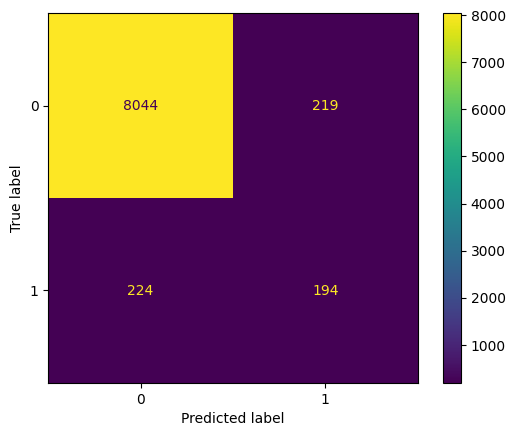

In [8]:
ConfusionMatrixDisplay.from_estimator(model_dt,X_test,y_test);

# Feature Importance

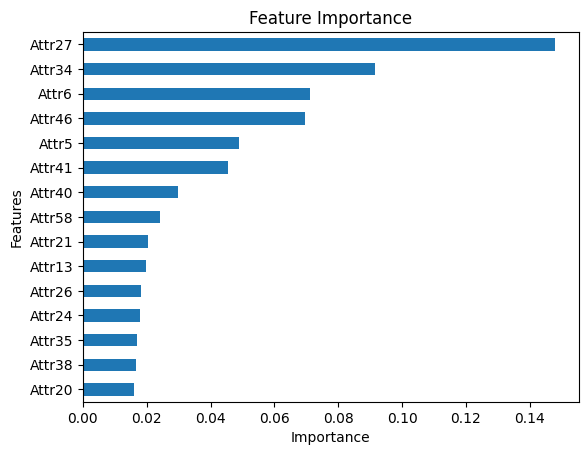

In [9]:
importances = model_dt.best_estimator_.named_steps["decisiontreeclassifier"].feature_importances_
features = X_train_over.columns
feat_imp = pd.Series(importances, index=features).sort_values()

feat_imp.tail(15).plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features");

**Best hyperparmeters**

In [11]:
best_params_dt = model_dt.best_params_
best_score_dt = model_dt.best_score_
best_model_dt = model_dt.best_estimator_


print("Best Model:", best_model_dt)
print("Best params:", best_params_dt)
print("Best Score:", best_score_dt)

Best Model: Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=40, random_state=42))])
Best params: {'decisiontreeclassifier__max_depth': 40, 'decisiontreeclassifier__min_samples_split': 2, 'simpleimputer__strategy': 'mean'}
Best Score: 0.9849929300346341


# Classification Report For Decision Tree Classifier

In [12]:
report_dt = classification_report(y_test, model_dt.predict(X_test))
print(report_dt)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      8263
           1       0.47      0.46      0.47       418

    accuracy                           0.95      8681
   macro avg       0.72      0.72      0.72      8681
weighted avg       0.95      0.95      0.95      8681



**Report for the decision tree classifier**

From the above we observed that there are features that significantly contirbute to model performance, while other do not have too much importance. Therefore we sall trainthe model with the most important features

# Training  the Desion Tree Model and all other models with reduced Features

**Extracting top_20 Features**

Top 20 Features (20):
 ['Attr36', 'Attr3', 'Attr9', 'Attr55', 'Attr29', 'Attr20', 'Attr38', 'Attr35', 'Attr24', 'Attr26', 'Attr13', 'Attr21', 'Attr58', 'Attr40', 'Attr41', 'Attr5', 'Attr46', 'Attr6', 'Attr34', 'Attr27']


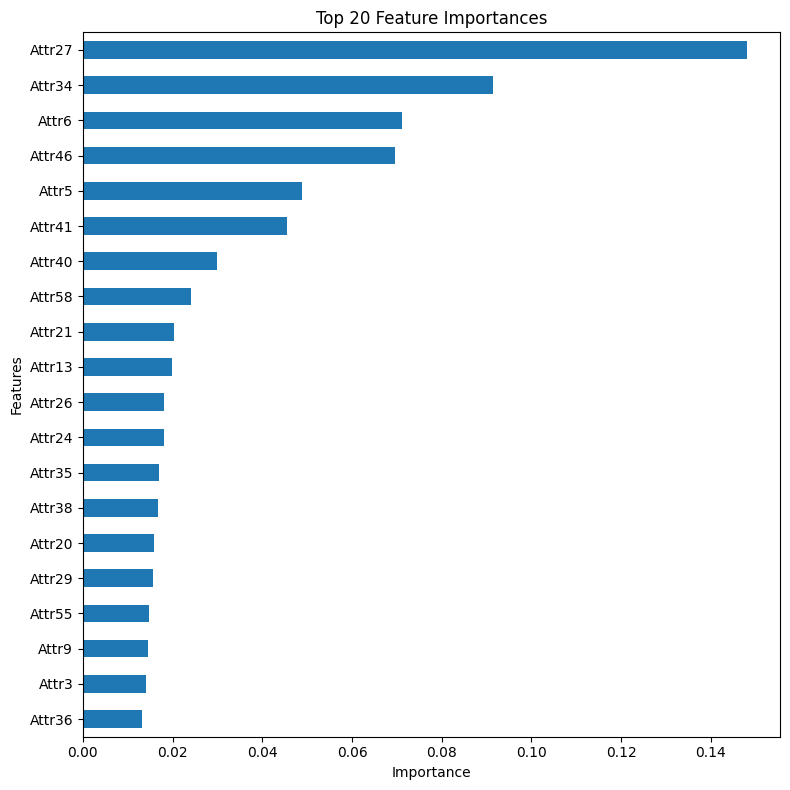

In [13]:
# Extract importances
importances = model_dt.best_estimator_.named_steps["decisiontreeclassifier"].feature_importances_
features = X_train_over.columns
feat_imp = pd.Series(importances, index=features).sort_values()


# Select top 25 features
top_20_features = feat_imp.tail(20).index.tolist()
print(f"Top 20 Features ({len(top_20_features)}):\n", top_20_features)

# Plot for the top_20 features
feat_imp.tail(20).sort_values().plot(kind="barh", figsize=(8, 8))
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## Trimming the Train and Test sets to 20 Features only

In [14]:
X_train_over = X_train_over[top_20_features]
X_test = X_test[top_20_features]
features = X_train_over.columns

print(f"X_train_over shape: {X_train_over.shape}")
print(f"X_test shape:       {X_test.shape}")

X_train_over shape: (66102, 20)
X_test shape:       (8681, 20)


## Decision Tree with the top_20 features

In [15]:
#Classifier for Decision Tree
classifier_dt2 = make_pipeline(
    SimpleImputer(),
    DecisionTreeClassifier(random_state=42)
)

# Cross Validation
cross_val_scores_dt = cross_val_score(classifier_dt2, X_train_over, y_train_over, cv=5, n_jobs=-1)

#hyperparameter Tuning
params_dt2 = {
    "decisiontreeclassifier__max_depth": range(10, 50, 10),
    "decisiontreeclassifier__min_samples_split": range(2, 10, 2),
    "simpleimputer__strategy": ["mean", "median"]
}
params_dt2

#GridSearchCV
model_dt2 = GridSearchCV(
    classifier_dt2,
    param_grid=params_dt2,
    cv=5,
    n_jobs=-1,
    verbose=1
)
model_dt2.fit(X_train_over, y_train_over)



Fitting 5 folds for each of 32 candidates, totalling 160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'decisiontreeclassifier__max_depth': range(10, 50, 10), 'decisiontreeclassifier__min_samples_split': range(2, 10, 2), 'simpleimputer__strategy': ['mean', 'median']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the co

## Best hyperparameters

In [16]:
best_params_dt2 = model_dt2.best_params_
best_score_dt2 = model_dt2.best_score_
best_model_dt2 = model_dt2.best_estimator_


print("Best Model:", best_model_dt2)
print("Best params:", best_params_dt2)
print("Best Score:", best_score_dt2)

Best Model: Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=40, random_state=42))])
Best params: {'decisiontreeclassifier__max_depth': 40, 'decisiontreeclassifier__min_samples_split': 2, 'simpleimputer__strategy': 'mean'}
Best Score: 0.9836464989854197


## Classification report for Decision Tree model with 20 Features

In [17]:
report_dt2 = classification_report(y_test, model_dt2.predict(X_test))
print(report_dt2)

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      8263
           1       0.48      0.45      0.47       418

    accuracy                           0.95      8681
   macro avg       0.73      0.71      0.72      8681
weighted avg       0.95      0.95      0.95      8681



## Ensemble Methods 
**Ensemble Methods work by building multiple models on random subsets of the same data,compare predictionsand make final predictions**
***The Random Froest Classifier***

In [18]:
# A classifier that uses random forest
classifier = make_pipeline(
    SimpleImputer(),
    RandomForestClassifier(random_state=42)
)

# Cross Validation
cross_val_scores = cross_val_score(classifier,X_train_over,y_train_over,cv=5,n_jobs=-1)

**Hyperparameter Tuning**

In [19]:
params = {
    "randomforestclassifier__n_estimators": range(25,100,25),
    "randomforestclassifier__max_depth":range(10,50,10),
    "simpleimputer__strategy": ["mean","median"]
}
params

{'randomforestclassifier__n_estimators': range(25, 100, 25),
 'randomforestclassifier__max_depth': range(10, 50, 10),
 'simpleimputer__strategy': ['mean', 'median']}

**The GridSearchCV**

In [20]:
model_rf = GridSearchCV(
    classifier,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1
)
model_rf.fit(X_train_over,y_train_over)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestclassifier__max_depth': range(10, 50, 10), 'randomforestclassifier__n_estimators': range(25, 100, 25), 'simpleimputer__strategy': ['mean', 'median']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comp

In [21]:
results = model_rf.cv_results_
cv_results = pd.DataFrame(results)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestclassifier__max_depth,param_randomforestclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,2.554800,0.031925,0.035159,0.000807,10,25,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.940625,0.939415,0.945991,0.944856,0.937292,0.941636,0.003291,23
1,2.611651,0.050716,0.034909,0.000749,10,25,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.940700,0.937145,0.940545,0.942965,0.943495,0.940970,0.002247,24
2,4.960656,0.026439,0.057365,0.000300,10,50,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.943802,0.941684,0.947806,0.945083,0.943343,0.944344,0.002045,21
3,5.012366,0.031388,0.056803,0.000611,10,50,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.944180,0.942970,0.944100,0.942663,0.942663,0.943315,0.000683,22
4,7.395812,0.026312,0.080217,0.000832,10,75,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.943953,0.943877,0.947277,0.947352,0.947126,0.945917,0.001636,19


# Extracting the best hyperparameters

In [22]:
best_params_rf = model_rf.best_params_
best_score_rf = model_rf.best_score_
best_model_rf = model_rf.best_estimator_


print("Best Model:", best_model_rf)
print("Best params:", best_params_rf)
print("Best Score:", best_score_rf)

Best Model: Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=40, n_estimators=75,
                                        random_state=42))])
Best params: {'randomforestclassifier__max_depth': 40, 'randomforestclassifier__n_estimators': 75, 'simpleimputer__strategy': 'median'}
Best Score: 0.9972769562383046


# Classification Report

In [23]:
classification_report= classification_report(y_test,model_rf.predict(X_test))
print(classification_report)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      8263
           1       0.87      0.39      0.54       418

    accuracy                           0.97      8681
   macro avg       0.92      0.69      0.76      8681
weighted avg       0.97      0.97      0.96      8681



# Confusion Matrix on Test Set

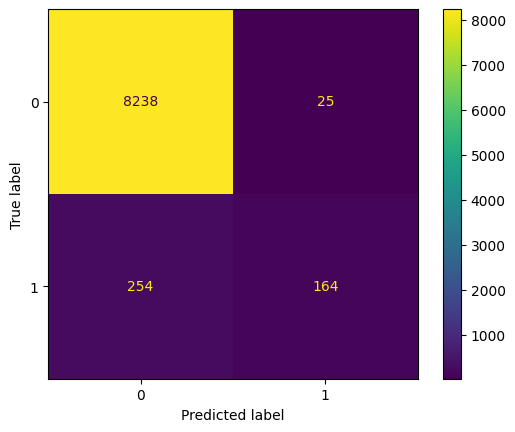

In [24]:
ConfusionMatrixDisplay.from_estimator(model_rf,X_test,y_test);

# Feauture Importance

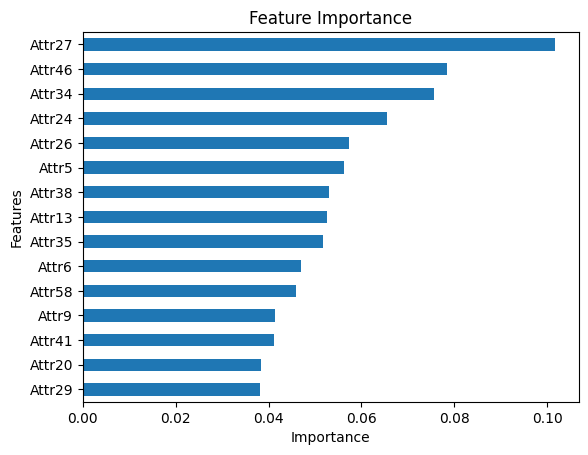

In [25]:
best_model_rf = model_rf.best_estimator_

importances = best_model_rf.named_steps["randomforestclassifier"].feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values()

feat_imp.tail(15).plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features");

# GRADIENT BOOSTING TREES
**Fitting multiple models in sequembnce using all the training data**


In [26]:
# A classifier that uses random forest
clf = make_pipeline(
    SimpleImputer(),
    GradientBoostingClassifier(random_state=42)
)

# Cross Validation
cross_val_scores = cross_val_score(classifier,X_train_over,y_train_over,cv=5,n_jobs=-1)

# Hyperparameter Tuning

In [27]:
params = {
    "simpleimputer__strategy": ["mean","median"],
    "gradientboostingclassifier__n_estimators": range(20,37,5),
    "gradientboostingclassifier__max_depth":range(2,5)    
}
params

{'simpleimputer__strategy': ['mean', 'median'],
 'gradientboostingclassifier__n_estimators': range(20, 37, 5),
 'gradientboostingclassifier__max_depth': range(2, 5)}

In [28]:
model_boost = GridSearchCV(
    clf,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1
)
model_boost.fit(X_train_over,y_train_over)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gradientboostingclassifier__max_depth': range(2, 5), 'gradientboostingclassifier__n_estimators': range(20, 37, 5), 'simpleimputer__strategy': ['mean', 'median']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comp

In [29]:
results_boost = model_boost.cv_results_
cv_results_boost = pd.DataFrame(results_boost)
cv_results_boost.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_gradientboostingclassifier__max_depth,param_gradientboostingclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,3.666989,0.192720,0.015402,0.001052,2,20,mean,"{'gradientboostingclassifier__max_depth': 2, '...",0.766659,0.777173,0.773828,0.774357,0.776626,0.773729,0.003759,23
1,3.555477,0.034271,0.014895,0.000099,2,20,median,"{'gradientboostingclassifier__max_depth': 2, '...",0.768021,0.772105,0.769440,0.769592,0.777761,0.771384,0.003449,24
2,4.348714,0.036248,0.016109,0.000355,2,25,mean,"{'gradientboostingclassifier__max_depth': 2, '...",0.776719,0.777475,0.776929,0.775340,0.790393,0.779371,0.005556,22
3,4.404215,0.028093,0.016302,0.001068,2,25,median,"{'gradientboostingclassifier__max_depth': 2, '...",0.782770,0.785342,0.790091,0.788654,0.784947,0.786361,0.002650,20
4,5.200753,0.011845,0.016401,0.000094,2,30,mean,"{'gradientboostingclassifier__max_depth': 2, '...",0.779896,0.783375,0.779501,0.780030,0.793797,0.783320,0.005421,21


In [30]:
best_params_boost = model_boost.best_params_
best_score_boost = model_boost.best_score_
best_model_boost = model_boost.best_estimator_


print("Best Model:", best_model_boost)
print("Best params:", best_params_boost)
print("Best Score:", best_score_boost)

Best Model: Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=35,
                                            random_state=42))])
Best params: {'gradientboostingclassifier__max_depth': 4, 'gradientboostingclassifier__n_estimators': 35, 'simpleimputer__strategy': 'median'}
Best Score: 0.8649512139777628


# The Classification Report

In [36]:
report_boost = classification_report(y_test,model_boost.predict(X_test) )
print(report_boost)

              precision    recall  f1-score   support

           0       0.99      0.85      0.91      8263
           1       0.22      0.81      0.34       418

    accuracy                           0.85      8681
   macro avg       0.60      0.83      0.63      8681
weighted avg       0.95      0.85      0.89      8681



# Feauture Importance

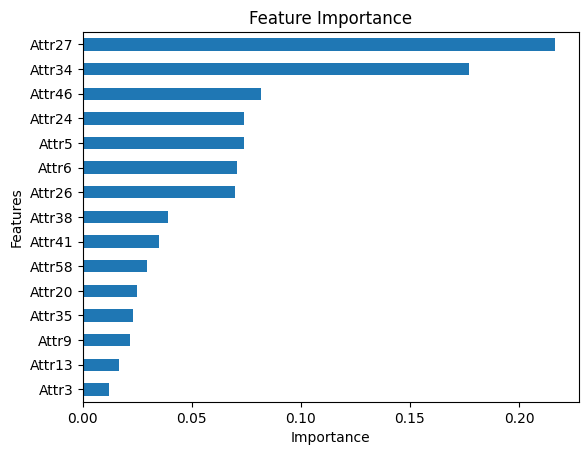

In [37]:
importances = best_model_boost.named_steps["gradientboostingclassifier"].feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values()

feat_imp = pd.Series(importances, index=features).sort_values()

feat_imp.tail(15).plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features");

# Interactive Dashboard

In [38]:

def make_cnf_matrix(threshold):
    y_pred_proba = model_boost.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)

    conf_matrix = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()
    print(f"Profit: {tp*100_000_000}")
    print(f"Losses: {fp*250_000_000}")
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    print(f"Accuracy : {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall   : {recall:.2f}")

    print("Confusion Matrix:")
    print(conf_matrix)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False)


thresh_widget = widgets.FloatSlider(min=0, max=1, value=0.5, step=0.05)
interact(make_cnf_matrix, threshold=thresh_widget);
    

interactive(children=(FloatSlider(value=0.5, description='threshold', max=1.0, step=0.05), Output()), _dom_cla…

# Saving the Models

In [41]:
os.makedirs("models", exist_ok=True)

# Saving all the models
with open("models/model_rf.pkl", "wb") as f:
    pickle.dump(model_rf.best_estimator_, f)

with open("models/model_dt2.pkl", "wb") as f:
    pickle.dump(model_dt2.best_estimator_, f)

with open("models/model_dt.pkl", "wb") as f:
    pickle.dump(model_dt.best_estimator_, f)

with open("models/model_boost.pkl", "wb") as f:
    pickle.dump(model_boost.best_estimator_, f)

print("Best estimators")
print(f"RF Best Params:    {model_rf.best_params_}")
print(f"DT2 Best Params:    {model_dt2.best_params_}")
print(f"DT Best Params:    {model_dt.best_params_}")

print(f"Boost Best Params: {model_boost.best_params_}")


Best estimators
RF Best Params:    {'randomforestclassifier__max_depth': 40, 'randomforestclassifier__n_estimators': 75, 'simpleimputer__strategy': 'median'}
DT2 Best Params:    {'decisiontreeclassifier__max_depth': 40, 'decisiontreeclassifier__min_samples_split': 2, 'simpleimputer__strategy': 'mean'}
DT Best Params:    {'decisiontreeclassifier__max_depth': 40, 'decisiontreeclassifier__min_samples_split': 2, 'simpleimputer__strategy': 'mean'}
Boost Best Params: {'gradientboostingclassifier__max_depth': 4, 'gradientboostingclassifier__n_estimators': 35, 'simpleimputer__strategy': 'median'}
